# **Module_3: Fibrosis**

## **Team Members:** Theresa Breckley and Mohamed Elfaki

## **Project Title:** Spatial Distribution of Fibrotic Tissue in Mouse Lung


## **Project Goal:**

This project aims to quantify how fibrotic tissue varies across lung depth using segmented image data, and to evaluate how well interpolation methods can estimate fibrosis at unmeasured depths. Additionally, the project explores whether fibrosis is uniformly distributed and assesses the reliability of predictions based on limited data.

### **Project Questions:**
* How does the percentage of fibrotic tissue change with tissue depth?
* Is fibrosis distributed uniformly through lung tissue?
* Can interpolation accuraltely estimate fibrosis at unmeasured depths?
* How reliable are predictions based on limited or sparse data?

## **Disease Background:** 

### **Prevalence and Incidence**

Idiopathic Pulmonary Fibrosis (IPF) is a chronic and progressive interstitial lung disease characterized by irreversible scarring of lung tissue. It is considered relatively rare, with an estimated prevalence of approximately 13–20 cases per 100,000 individuals in the United States. The disease primarily affects older adults, most commonly those over the age of 60, and occurs more frequently in men than in women. Despite its relatively low prevalence, IPF carries a poor prognosis, with a median survival time of only 3–5 years following diagnosis.

### **Risk Factors**

Several risk factors are associated with the development of IPF, although the exact cause remains unknown. Age is the most significant factor, with incidence increasing substantially in older populations. A history of smoking is strongly linked to increased risk, as are environmental and occupational exposures such as metal dust, wood dust, and other airborne pollutants. Genetic predisposition also plays a role, particularly in individuals with family histories of pulmonary fibrosis or mutations affecting surfactant production and telomere maintenance. Additionally, conditions like gastroesophageal reflux disease (GERD) may contribute to repeated lung injury, further increasing risk.

### **Symptoms**

The symptoms of IPF are typically gradual in onset and worsen over time. The most common symptom is progressive shortness of breath, especially during physical activity, which reflects declining lung function. Patients also frequently experience a persistent dry cough, fatigue, and general weakness. As the disease advances, unintended weight loss may occur, and some individuals develop digital clubbing, a condition characterized by the enlargement of the fingertips. These symptoms significantly impact quality of life and become more severe as fibrosis progresses.

### **Standard of Care/Treatment**
    
There is currently no cure for IPF, and treatment focuses on slowing disease progression and managing symptoms. Two primary antifibrotic medications, Pirfenidone and Nintedanib, are commonly prescribed to reduce the rate of lung function decline. Supplemental oxygen therapy is often used to address low blood oxygen levels, while pulmonary rehabilitation programs help improve physical endurance and overall quality of life. For eligible patients, lung transplantation remains the only definitive treatment option. In addition to these interventions, supportive care is essential to manage symptoms and improve patient comfort.

### **Biological Mechanisms (Pathophysiology)**

IPF is driven by repeated micro-injury to the alveolar epithelium, particularly affecting type I and type II pneumocytes, which are essential for gas exchange and surfactant production. Instead of normal tissue repair, the lungs undergo an abnormal healing response characterized by excessive activation of fibroblasts. These cells produce large amounts of collagen and extracellular matrix, leading to thickening and stiffening of lung tissue. This fibrotic remodeling disrupts the alveolar-capillary interface, impairing oxygen diffusion into the bloodstream. As fibrosis progresses, lung compliance decreases, making it more difficult for the lungs to expand, ultimately leading to reduced oxygenation and respiratory failure.

### **Economic Burden and Public Health Impact**

Idiopathic Pulmonary Fibrosis (IPF) places a substantial economic burden on both patients and the healthcare system due to its chronic and progressive nature. Patients often require ongoing care, including frequent medical visits, diagnostic testing, and long-term use of costly antifibrotic medications such as Pirfenidone and Nintedanib. In addition to direct medical costs, many individuals experience reduced ability to work or early retirement, leading to lost income and increased financial strain. Caregivers may also face economic challenges due to time and resource demands. At a broader level, increased hospitalizations and advanced treatments, including oxygen therapy and lung transplantation, further strain healthcare systems. As the population ages, the economic impact of IPF is expected to grow, emphasizing the need for improved management and early intervention.

## **Data-Set:**

The dataset used in this project consists of unpublished biomedical imaging data collected by the Peirce-Cottler Lab (Department of Biomedical Engineering) and the Kim Lab (Division of Pulmonary and Critical Care) at the University of Virginia School of Medicine. It includes microscopy images of lung tissue samples along with corresponding segmentation masks that isolate regions of interest, such as fibrotic tissue. Each image is associated with a depth value, indicating its position within the tissue, allowing for analysis of spatial variation in fibrosis. The data are organized through structured filenames that encode information about sample region, imaging conditions, and acquisition order, enabling consistent pairing of images, masks, and metadata.

The primary variables analyzed are derived from image processing, including pixel intensity values and the proportion of masked regions, which serve as indicators of tissue structure and fibrosis extent. These values are measured in pixel units, with comparisons made relative across samples. Preprocessing steps include loading image–mask pairs, converting images to numerical arrays, and applying masks to isolate relevant regions. The analysis assumes that masks accurately represent areas of interest and that image quality and depth measurements are consistent. Limitations of the dataset include its relatively small size, lack of clinical metadata, potential variability in imaging conditions, and possible inaccuracies in segmentation, all of which may impact the generalizability and precision of results.

## **Data Analyis:** 


### **Fibrotic Tissue at Different Depths**

To investigate how fibrosis changes throughout lung tissue, segmented binary images were analyzed at multiple depths. In these images, white pixels represent fibrotic tissue, while black pixels represent non-fibrotic regions.

For each image, the number of white and black pixels was calculated and used to determine the percentage of fibrotic tissue. These values were then paired with their corresponding imaging depths to create a dataset describing fibrosis as a function of depth.

By analyzing this relationship, we aim to determine whether fibrosis is evenly distributed throughout the tissue or varies across different regions.

                        Filename  Depth (microns)  White pixels  Black pixels  \
0  MASK_SK658 Llobe ch010039.jpg               15         21648       4172656   
1  MASK_SK658 Llobe ch010021.jpg               30         23900       4170404   
2  MASK_SK658 Llobe ch010017.jpg               45         27561       4166743   
3  MASK_SK658 Llobe ch010036.jpg               55         29677       4164627   
4  MASK_SK658 Llobe ch010019.jpg               60         31331       4162973   

   White percent  
0       0.516129  
1       0.569820  
2       0.657105  
3       0.707555  
4       0.746989  
Pixel count check passed: True


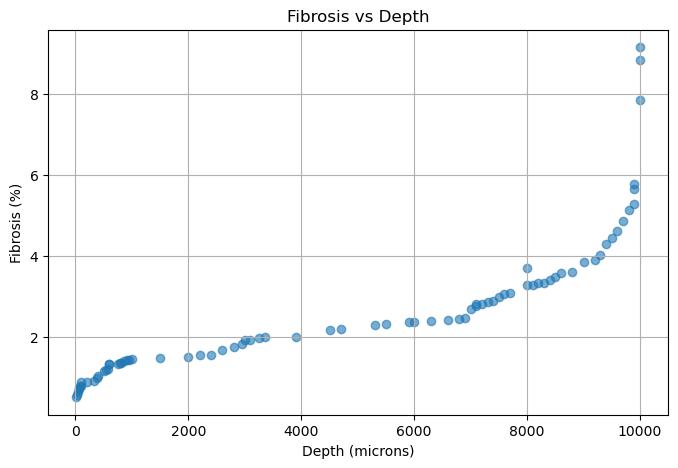

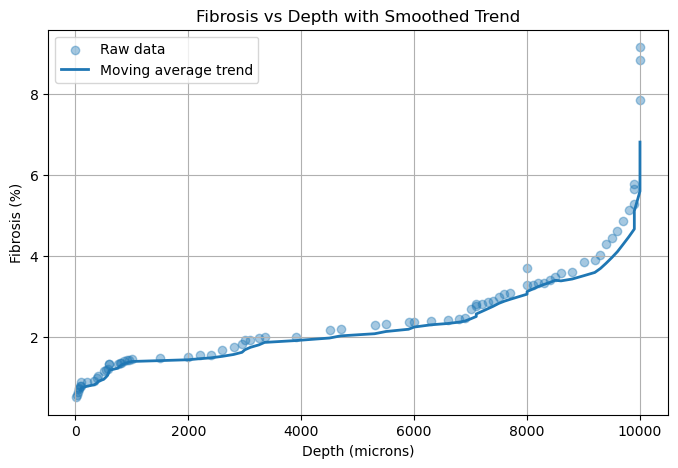

In [1]:
# ---------------------------
# Import Libraries
# ---------------------------
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# ---------------------------
# Load CSV with filenames + depths
# ---------------------------
csv_path = r"C:\Users\15712\OneDrive - University of Virginia\Comp Mod 3\Module-3-Fibrosisb-breckley_elfaki\Filenames and Depths for Students.csv"
df_files = pd.read_csv(csv_path)


filename_col = df_files.columns[0]
depth_col = df_files.columns[1]

# ---------------------------
# Full path to image folder
# ---------------------------
image_folder = r"C:\Users\15712\OneDrive - University of Virginia\Comp Mod 3\Module-3-Fibrosisb-breckley_elfaki\images"

# ---------------------------
# Function to calculate pixel data
# ---------------------------
def calculate_fibrosis(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        print(f"Warning: Could not load {image_path}")
        return None, None, None

    # Binary threshold
    _, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

    # Pixel counts
    white_pixels = np.sum(binary == 255)
    total_pixels = binary.size
    black_pixels = total_pixels - white_pixels

    # Percentage
    white_percent = (white_pixels / total_pixels) * 100

    return white_pixels, black_pixels, white_percent

# ---------------------------
# Process all images
# ---------------------------
filenames_used = []
depths = []
white_values = []
black_values = []
percent_values = []

for _, row in df_files.iterrows():
    filename = str(row[filename_col]).strip()

    # Remove extra folder text if present
    filename = filename.replace("images/", "").replace("images\\", "")

    depth = row[depth_col]

    image_path = os.path.join(image_folder, filename)

    if not os.path.exists(image_path):
        print("Missing file:", image_path)
        continue

    white, black, percent = calculate_fibrosis(image_path)

    if white is not None:
        filenames_used.append(filename)
        depths.append(depth)
        white_values.append(white)
        black_values.append(black)
        percent_values.append(percent)

# ---------------------------
# Create DataFrame
# ---------------------------
results_df = pd.DataFrame({
    "Filename": filenames_used,
    "Depth (microns)": depths,
    "White pixels": white_values,
    "Black pixels": black_values,
    "White percent": percent_values
})

# Convert depth to numeric and sort
results_df["Depth (microns)"] = pd.to_numeric(results_df["Depth (microns)"], errors="coerce")
results_df = results_df.dropna()
results_df = results_df.sort_values(by="Depth (microns)")

# ---------------------------
# Save CSV file
# ---------------------------
output_csv = r"C:\Users\15712\OneDrive - University of Virginia\Comp Mod 3\Module-3-Fibrosisb-breckley_elfaki\fibrosis_vs_depth_results.csv"
results_df.to_csv(output_csv, index=False)

print(results_df.head())

# ---------------------------
# Verification check
# ---------------------------
total_pixels_check = np.array(white_values) + np.array(black_values)
print("Pixel count check passed:", np.all(total_pixels_check > 0))

# ---------------------------
# Plot RAW data
# ---------------------------
x = results_df["Depth (microns)"].values
y = results_df["White percent"].values

plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.6)
plt.xlabel("Depth (microns)")
plt.ylabel("Fibrosis (%)")
plt.title("Fibrosis vs Depth")
plt.grid(True)
plt.show()

# ---------------------------
# Moving Average Trend Line
# ---------------------------
# Sort data (just to be safe)
sort_idx = np.argsort(x)
x_sorted = x[sort_idx]
y_sorted = y[sort_idx]

# Moving average
window = 7
y_smooth = np.convolve(y_sorted, np.ones(window)/window, mode='valid')
x_smooth = x_sorted[window-1:]

plt.figure(figsize=(8, 5))
plt.scatter(x_sorted, y_sorted, alpha=0.4, label="Raw data")
plt.plot(x_smooth, y_smooth, linewidth=2, label="Moving average trend")
plt.xlabel("Depth (microns)")
plt.ylabel("Fibrosis (%)")
plt.title("Fibrosis vs Depth with Smoothed Trend")
plt.grid(True)
plt.legend()
plt.show()

def plot_zoom(x, y, xmin, xmax, title):
    mask = (x >= xmin) & (x <= xmax)
    
    x_zoom = x[mask]
    y_zoom = y[mask]
    
    if len(x_zoom) == 0:
        print(f"No data in range {xmin}-{xmax}")
        return
    
    
    plt.figure(figsize=(7,4))
    plt.scatter(x_zoom, y_zoom, alpha=0.7)
    plt.xlabel("Depth (microns)")
    plt.ylabel("Fibrosis (%)")
    plt.title(title)
    plt.grid(True)
    plt.show()

**Overall Trend Analysis**

The full dataset shows that the percentage of fibrotic tissue generally increases with depth. At shallow depths, fibrosis levels are relatively low, while deeper regions exhibit higher percentages of fibrotic tissue.

However, the relationship is not perfectly linear. Instead, the data suggests a gradual increase followed by a more rapid rise at greater depths. This indicates that fibrosis accumulation is not uniform and may become more severe in deeper regions of the tissue.

Additionally, some variability is observed within the data, suggesting that fibrosis is not evenly distributed even at similar depths.

### **Localized Analysis of Fibrosis by Depth**

To better understand how fibrosis behaves at different regions of the tissue, the data was divided into three depth ranges: shallow (0–2000 microns), mid-depth (2000–6000 microns), and deep (6000–10000 microns).

Examining these regions individually allows for a more detailed analysis of how fibrotic tissue changes across the lung and helps identify patterns that may not be visible in the full dataset.

#### **0-2000 Microns**

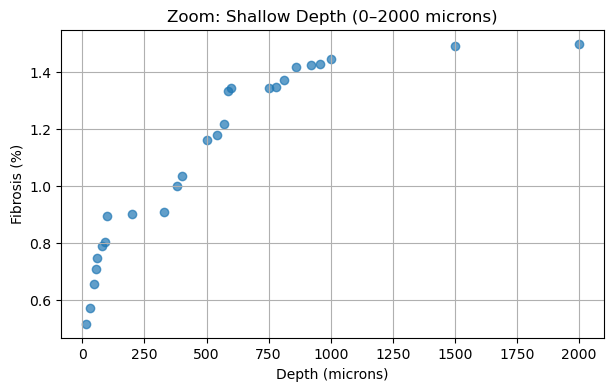

In [2]:
# Shallow region
plot_zoom(x, y, 0, 2000, "Zoom: Shallow Depth (0–2000 microns)")

The shallow region (0–2000 microns) shows relatively low fibrosis percentages, with values gradually increasing from approximately 0.5% to around 1.5%. The increase is steady, suggesting early-stage or less severe fibrotic involvement in these regions.

#### **2000-6000 Microns**

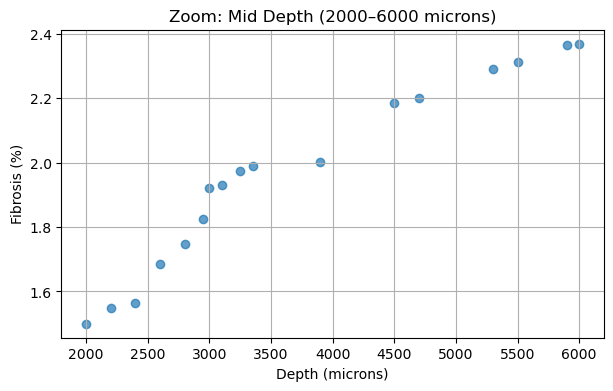

In [3]:
# Middle region
plot_zoom(x, y, 2000, 6000, "Zoom: Mid Depth (2000–6000 microns)")

In the mid-depth range (2000–6000 microns), fibrosis continues to increase at a moderate rate, reaching values around 2.3%. The trend remains relatively smooth, indicating a consistent progression of fibrosis through this portion of the tissue.

#### **6000-10000 Microns**

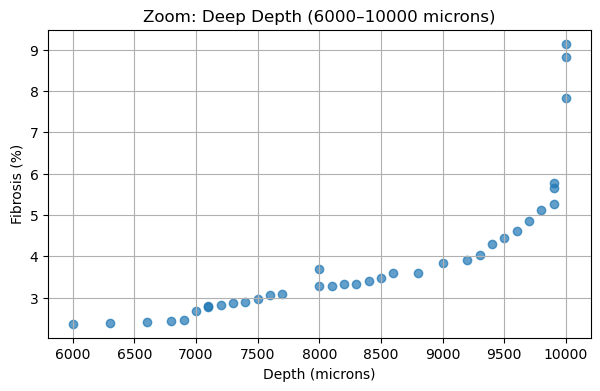

In [4]:
# Deep region
plot_zoom(x, y, 6000, 10000, "Zoom: Deep Depth (6000–10000 microns)")

In contrast, the deep region (6000–10000 microns) shows a more pronounced increase in fibrosis. While the lower end of this range begins near 2.5–3%, the upper depths exhibit a sharp rise, with some values exceeding 8–9%. This suggests that fibrosis becomes significantly more severe at greater depths.

Overall, these results indicate that fibrosis is not uniformly distributed throughout the lung tissue. Instead, fibrotic burden increases with depth and shows more rapid progression in deeper regions, highlighting the heterogeneous nature of the disease.

### **Interpolation:**

### **Larger Dataset**

In [5]:
# ---------------------------
# Interpolation comparison by region
# ---------------------------
from scipy.interpolate import interp1d
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def compare_interpolation_region_all_points(df, xmin, xmax, region_name):
    # Select region
    region_df = df[
        (df["Depth (microns)"] >= xmin) &
        (df["Depth (microns)"] <= xmax)
    ].copy()

    # Combine duplicate depths by averaging White percent
    region_df = (
        region_df.groupby("Depth (microns)", as_index=False)["White percent"]
        .mean()
        .sort_values(by="Depth (microns)")
        .reset_index(drop=True)
    )

    x_all = region_df["Depth (microns)"].values
    y_all = region_df["White percent"].values

    print(f"\n--- {region_name} Region ---")
    print(f"Total unique depth points in region: {len(region_df)}")

    if len(region_df) < 6:
        print("Not enough unique points in this region for interpolation comparison.")
        return None, None

    # Keep every other point
    train_df = region_df.iloc[::2].copy()
    test_df = region_df.iloc[1::2].copy()

    x_train = train_df["Depth (microns)"].values
    y_train = train_df["White percent"].values
    x_test = test_df["Depth (microns)"].values
    y_test = test_df["White percent"].values

    # Only test points inside interpolation range
    valid_mask = (x_test >= x_train.min()) & (x_test <= x_train.max())
    x_test = x_test[valid_mask]
    y_test = y_test[valid_mask]

    if len(x_test) == 0:
        print("No removed points fell inside the interpolation range.")
        return None, None

    # Linear interpolation
    linear_interp = interp1d(x_train, y_train, kind="linear")
    y_linear_pred = linear_interp(x_test)

    # Quadratic interpolation
    quadratic_possible = len(np.unique(x_train)) >= 3
    if quadratic_possible:
        quadratic_interp = interp1d(x_train, y_train, kind="quadratic")
        y_quad_pred = quadratic_interp(x_test)
    else:
        quadratic_interp = None
        y_quad_pred = np.full_like(y_test, np.nan, dtype=float)

    # Build comparison table for ALL removed points
    compare_df = pd.DataFrame({
        "Depth (microns)": x_test,
        "Actual fibrosis (%)": y_test,
        "Linear interpolation (%)": y_linear_pred,
        "Quadratic interpolation (%)": y_quad_pred,
        "Linear abs error": np.abs(y_linear_pred - y_test),
        "Quadratic abs error": np.abs(y_quad_pred - y_test)
    })

    # Percent errors
    compare_df["Linear percent error"] = np.where(
        compare_df["Actual fibrosis (%)"] != 0,
        compare_df["Linear abs error"] / compare_df["Actual fibrosis (%)"] * 100,
        np.nan
    )
    compare_df["Quadratic percent error"] = np.where(
        compare_df["Actual fibrosis (%)"] != 0,
        compare_df["Quadratic abs error"] / compare_df["Actual fibrosis (%)"] * 100,
        np.nan
    )

    print("\nComparison table for ALL removed points:")
    print(compare_df)

    # Reconstruct full datasets:
    # 1) original full data
    # 2) linear reconstruction = kept points + linear predictions
    # 3) quadratic reconstruction = kept points + quadratic predictions

    linear_reconstructed_df = pd.DataFrame({
        "Depth (microns)": np.concatenate([x_train, x_test]),
        "Fibrosis (%)": np.concatenate([y_train, y_linear_pred])
    }).sort_values(by="Depth (microns)")

    quadratic_reconstructed_df = pd.DataFrame({
        "Depth (microns)": np.concatenate([x_train, x_test]),
        "Fibrosis (%)": np.concatenate([y_train, y_quad_pred])
    }).sort_values(by="Depth (microns)")

    original_df = pd.DataFrame({
        "Depth (microns)": x_all,
        "Fibrosis (%)": y_all
    }).sort_values(by="Depth (microns)")

    # Plot all three curves together
    plt.figure(figsize=(9, 6))

    # Original full dataset
    plt.plot(
        original_df["Depth (microns)"],
        original_df["Fibrosis (%)"],
        marker="o",
        linestyle="-",
        linewidth=2,
        label="Original data"
    )

    # Linear reconstructed dataset
    plt.plot(
        linear_reconstructed_df["Depth (microns)"],
        linear_reconstructed_df["Fibrosis (%)"],
        marker="x",
        linestyle="-",
        linewidth=2,
        label="Linear interpolation + kept points"
    )

    # Quadratic reconstructed dataset
    if quadratic_possible:
        plt.plot(
            quadratic_reconstructed_df["Depth (microns)"],
            quadratic_reconstructed_df["Fibrosis (%)"],
            marker="^",
            linestyle="-",
            linewidth=2,
            label="Quadratic interpolation + kept points"
        )

    plt.xlabel("Depth (microns)")
    plt.ylabel("Fibrosis (%)")
    plt.title(f"{region_name} Region: Original vs Reconstructed Data")
    plt.grid(True)
    plt.legend()
    plt.show()

    # Summary metrics
    summary = {
        "Region": region_name,
        "Linear mean abs error": compare_df["Linear abs error"].mean(),
        "Quadratic mean abs error": compare_df["Quadratic abs error"].mean(),
        "Linear mean percent error": compare_df["Linear percent error"].mean(),
        "Quadratic mean percent error": compare_df["Quadratic percent error"].mean()
    }

    return compare_df, summary

#### **0-2000 Microns**


--- Shallow Region ---
Total unique depth points in region: 26

Comparison table for ALL removed points:
    Depth (microns)  Actual fibrosis (%)  Linear interpolation (%)  \
0                30             0.569820                  0.586617   
1                55             0.707555                  0.717028   
2                80             0.790381                  0.785375   
3               100             0.894260                  0.813352   
4               330             0.907612                  0.972554   
5               400             1.035309                  1.026718   
6               540             1.179957                  1.192641   
7               585             1.335216                  1.280308   
8               750             1.345134                  1.347184   
9               810             1.371646                  1.373732   
10              920             1.425457                  1.424084   
11             1000             1.447558              

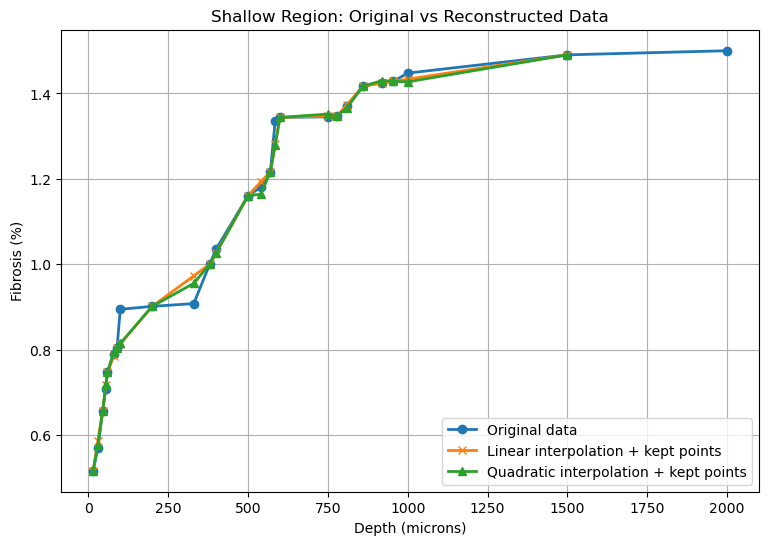

In [6]:
shallow_compare, shallow_summary = compare_interpolation_region_all_points(
    results_df, 0, 2000, "Shallow"
)

Both linear and quadratic interpolation closely follow the original data in the shallow region. The small differences between predicted and actual values indicate that interpolation is highly reliable when the data trend is smooth and gradual. This suggests that missing data in shallow regions can be accurately estimated.

#### **2000-6000 Microns**


--- Mid Region ---
Total unique depth points in region: 17

Comparison table for ALL removed points:
   Depth (microns)  Actual fibrosis (%)  Linear interpolation (%)  \
0             2200             1.550221                  1.532388   
1             2600             1.685977                  1.655304   
2             2950             1.825786                  1.876509   
3             3100             1.931524                  1.941538   
4             3350             1.988792                  1.978005   
5             4500             2.185178                  2.150124   
6             5300             2.289104                  2.284980   
7             5900             2.363467                  2.357635   

   Quadratic interpolation (%)  Linear abs error  Quadratic abs error  \
0                     1.522117          0.017834             0.028104   
1                     1.628049          0.030673             0.057928   
2                     1.884187          0.050724         

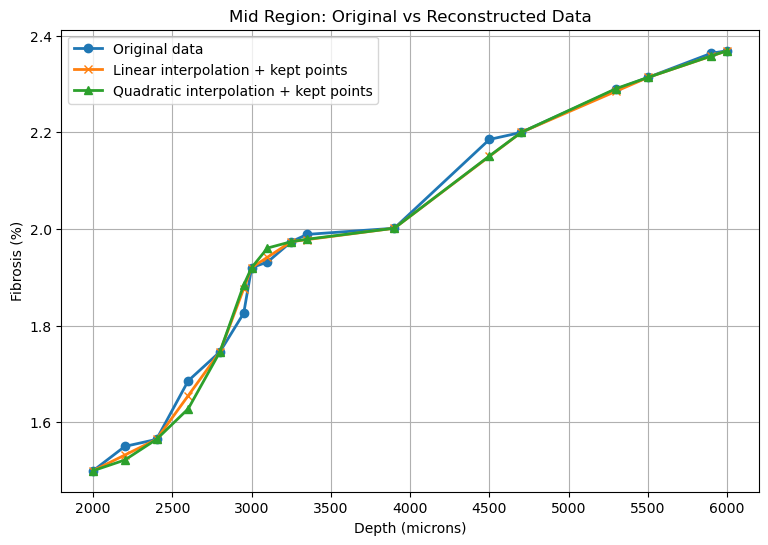

In [7]:
mid_compare, mid_summary = compare_interpolation_region_all_points(
    results_df, 2000, 6000, "Mid"
)

In the mid-depth region, interpolation methods still perform well, with reconstructed curves closely matching the original dataset. Linear interpolation slightly underestimates some values, while quadratic interpolation captures curvature more effectively. Overall, both methods remain reasonably accurate in regions with steady trends.

#### **6000-10000**


--- Deep Region ---
Total unique depth points in region: 31

Comparison table for ALL removed points:
    Depth (microns)  Actual fibrosis (%)  Linear interpolation (%)  \
0              6300             2.389812                  2.391732   
1              6800             2.439857                  2.451221   
2              7000             2.684903                  2.630591   
3              7200             2.823091                  2.825642   
4              7400             2.882719                  2.917898   
5              7600             3.064561                  3.033161   
6              8000             3.488195                  3.234571   
7              8200             3.327107                  3.308129   
8              8400             3.394103                  3.405178   
9              8600             3.589535                  3.518979   
10             9000             3.841186                  3.752351   
11             9300             4.027653                 

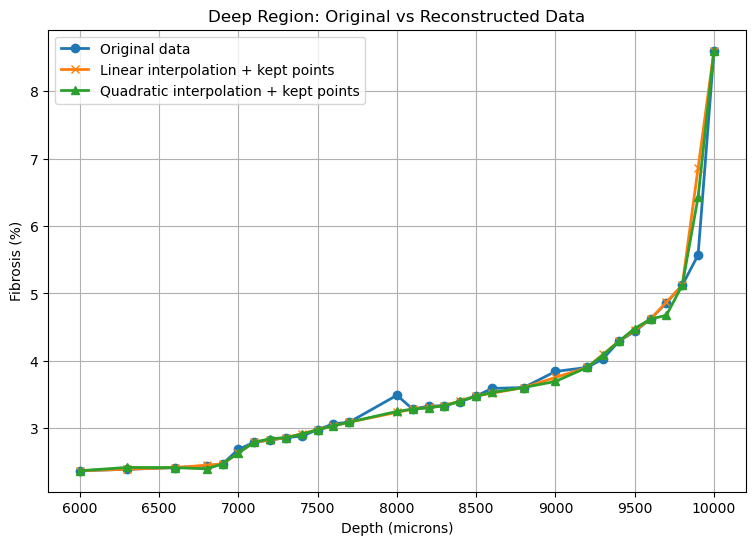

In [8]:
deep_compare, deep_summary = compare_interpolation_region_all_points(
    results_df, 6000, 10000, "Deep"
)

In the deep region, interpolation becomes less accurate, especially at higher depths where fibrosis increases rapidly. Both linear and quadratic methods struggle to capture sharp changes in the data. This indicates that interpolation is less reliable in regions with nonlinear or accelerating behavior.

#### **Error**

In [9]:
# ---------------------------
# Summary table
# ---------------------------
summary_df = pd.DataFrame([
    shallow_summary,
    mid_summary,
    deep_summary
])

print("\nAverage interpolation error summary:")
print(summary_df)


Average interpolation error summary:
    Region  Linear mean abs error  Quadratic mean abs error  \
0  Shallow               0.022745                  0.022554   
1      Mid               0.020630                  0.028076   
2     Deep               0.130983                  0.121451   

   Linear mean percent error  Quadratic mean percent error  
0                   2.376358                      2.241524  
1                   1.104971                      1.539223  
2                   2.852213                      2.827606  


The error summary shows that interpolation accuracy varies by region. Errors are lowest in the shallow and mid regions, where trends are smoother, and highest in the deep region, where fibrosis changes more rapidly. This confirms that interpolation reliability depends on the underlying behavior of the data.

### **Limited Dataset**

In [10]:
# ---------------------------
# Three-point interpolation by region
# Keep first, median, and last points
# ---------------------------
from scipy.interpolate import interp1d
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def three_point_interpolation_region(df, xmin, xmax, region_name):
    # Select region
    region_df = df[
        (df["Depth (microns)"] >= xmin) &
        (df["Depth (microns)"] <= xmax)
    ].copy()

    # Combine duplicate depths by averaging White percent
    region_df = (
        region_df.groupby("Depth (microns)", as_index=False)["White percent"]
        .mean()
        .sort_values(by="Depth (microns)")
        .reset_index(drop=True)
    )

    x_all = region_df["Depth (microns)"].values
    y_all = region_df["White percent"].values

    print(f"\n--- {region_name} Region ---")
    print(f"Total unique depth points in region: {len(region_df)}")

    if len(region_df) < 5:
        print("Not enough points in this region for three-point interpolation.")
        return None, None

    # Keep first, median, and last points
    mid_index = len(region_df) // 2
    keep_indices = sorted(list(set([0, mid_index, len(region_df) - 1])))

    train_df = region_df.iloc[keep_indices].copy()
    test_df = region_df.drop(index=keep_indices).copy()

    x_train = train_df["Depth (microns)"].values
    y_train = train_df["White percent"].values
    x_test = test_df["Depth (microns)"].values
    y_test = test_df["White percent"].values

    # Only keep test points inside interpolation range
    valid_mask = (x_test >= x_train.min()) & (x_test <= x_train.max())
    x_test = x_test[valid_mask]
    y_test = y_test[valid_mask]

    if len(x_test) == 0:
        print("No removed points fell inside the interpolation range.")
        return None, None

    # Linear interpolation
    linear_interp = interp1d(x_train, y_train, kind="linear")
    y_linear_pred = linear_interp(x_test)

    # Quadratic interpolation
    quadratic_interp = interp1d(x_train, y_train, kind="quadratic")
    y_quad_pred = quadratic_interp(x_test)

    # Build comparison table for all removed points
    compare_df = pd.DataFrame({
        "Depth (microns)": x_test,
        "Actual fibrosis (%)": y_test,
        "Linear interpolation (%)": y_linear_pred,
        "Quadratic interpolation (%)": y_quad_pred,
        "Linear abs error": np.abs(y_linear_pred - y_test),
        "Quadratic abs error": np.abs(y_quad_pred - y_test)
    })

    compare_df["Linear percent error"] = np.where(
        compare_df["Actual fibrosis (%)"] != 0,
        compare_df["Linear abs error"] / compare_df["Actual fibrosis (%)"] * 100,
        np.nan
    )

    compare_df["Quadratic percent error"] = np.where(
        compare_df["Actual fibrosis (%)"] != 0,
        compare_df["Quadratic abs error"] / compare_df["Actual fibrosis (%)"] * 100,
        np.nan
    )

    print("\nComparison table for all removed points:")
    print(compare_df)

    # Reconstructed datasets
    original_df = pd.DataFrame({
        "Depth (microns)": x_all,
        "Fibrosis (%)": y_all
    }).sort_values(by="Depth (microns)")

    linear_reconstructed_df = pd.DataFrame({
        "Depth (microns)": np.concatenate([x_train, x_test]),
        "Fibrosis (%)": np.concatenate([y_train, y_linear_pred])
    }).sort_values(by="Depth (microns)")

    quadratic_reconstructed_df = pd.DataFrame({
        "Depth (microns)": np.concatenate([x_train, x_test]),
        "Fibrosis (%)": np.concatenate([y_train, y_quad_pred])
    }).sort_values(by="Depth (microns)")

    # Plot
    plt.figure(figsize=(9, 6))

    plt.plot(
        original_df["Depth (microns)"],
        original_df["Fibrosis (%)"],
        marker="o",
        linestyle="-",
        linewidth=2,
        label="Original data"
    )

    plt.plot(
        linear_reconstructed_df["Depth (microns)"],
        linear_reconstructed_df["Fibrosis (%)"],
        marker="x",
        linestyle="-",
        linewidth=2,
        label="Linear interpolation + kept points"
    )

    plt.plot(
        quadratic_reconstructed_df["Depth (microns)"],
        quadratic_reconstructed_df["Fibrosis (%)"],
        marker="^",
        linestyle="-",
        linewidth=2,
        label="Quadratic interpolation + kept points"
    )

    plt.scatter(
        x_train,
        y_train,
        s=110,
        marker="s",
        label="Kept points (first, median, last)"
    )

    plt.xlabel("Depth (microns)")
    plt.ylabel("Fibrosis (%)")
    plt.title(f"{region_name} Region: Three-Point Interpolation Comparison")
    plt.grid(True)
    plt.legend()
    plt.show()

    # Summary
    summary = {
        "Region": region_name,
        "Linear mean abs error": compare_df["Linear abs error"].mean(),
        "Quadratic mean abs error": compare_df["Quadratic abs error"].mean(),
        "Linear mean percent error": compare_df["Linear percent error"].mean(),
        "Quadratic mean percent error": compare_df["Quadratic percent error"].mean()
    }

    return compare_df, summary

#### **0-2000 Microns**


--- Shallow Region ---
Total unique depth points in region: 26

Comparison table for all removed points:
    Depth (microns)  Actual fibrosis (%)  Linear interpolation (%)  \
0                30             0.569820                  0.535095   
1                45             0.657105                  0.554062   
2                55             0.707555                  0.566706   
3                60             0.746989                  0.573028   
4                80             0.790381                  0.598317   
5                90             0.804567                  0.610961   
6               100             0.894260                  0.623606   
7               200             0.901198                  0.750049   
8               330             0.907612                  0.914426   
9               380             0.999999                  0.977648   
10              400             1.035309                  1.002936   
11              500             1.160312              

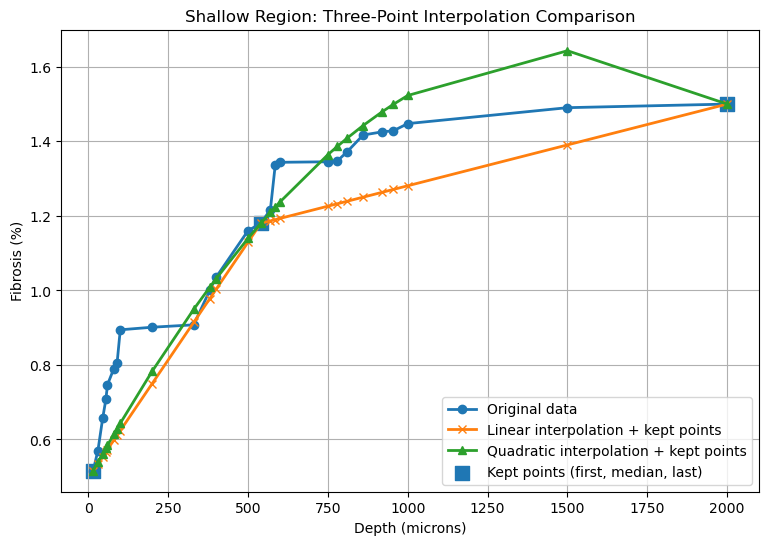

In [11]:
shallow_three_compare, shallow_three_summary = three_point_interpolation_region(
    results_df, 0, 2000, "Shallow"
)

Using only three points (first, median, last), interpolation becomes less accurate compared to using the full dataset. While general trends are still captured, there are noticeable deviations from the original data. This demonstrates that reducing data points decreases prediction accuracy.

#### **2000-6000 Microns**


--- Mid Region ---
Total unique depth points in region: 17

Comparison table for all removed points:
    Depth (microns)  Actual fibrosis (%)  Linear interpolation (%)  \
0              2200             1.550221                  1.575765   
1              2400             1.564813                  1.651567   
2              2600             1.685977                  1.727368   
3              2800             1.745796                  1.803170   
4              2950             1.825786                  1.860022   
5              3000             1.920080                  1.878972   
6              3100             1.931524                  1.916873   
7              3350             1.988792                  1.988087   
8              3900             2.001548                  2.067080   
9              4500             2.185178                  2.153254   
10             4700             2.199650                  2.181978   
11             5300             2.289104                  

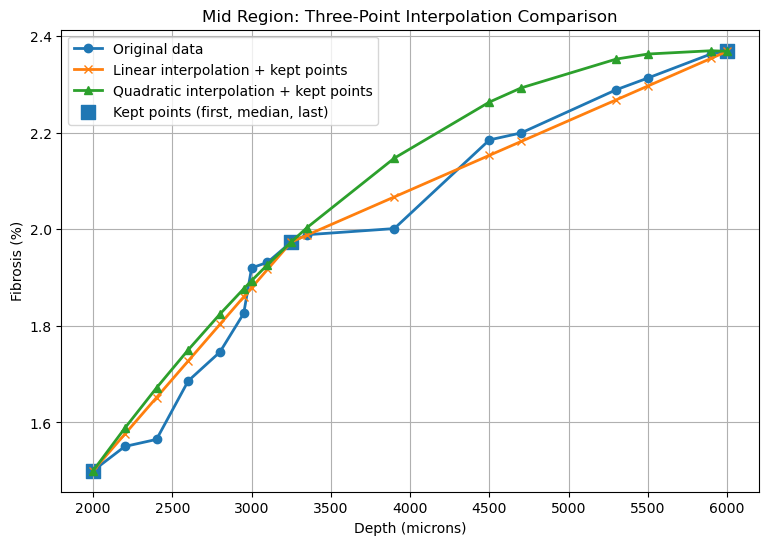

In [12]:
mid_three_compare, mid_three_summary = three_point_interpolation_region(
    results_df, 2000, 6000, "Mid"
)

In the mid region, three-point interpolation performs moderately well but still introduces some error. The reconstructed curves follow the overall trend but miss finer variations in the data. This suggests that limited data can approximate general behavior but lacks precision.

#### **6000-10000 Microns**


--- Deep Region ---
Total unique depth points in region: 31

Comparison table for all removed points:
    Depth (microns)  Actual fibrosis (%)  Linear interpolation (%)  \
0              6300             2.389812                  2.499382   
1              6600             2.414775                  2.630076   
2              6800             2.439857                  2.717205   
3              6900             2.469444                  2.760769   
4              7000             2.684903                  2.804334   
5              7100             2.791739                  2.847898   
6              7200             2.823091                  2.891462   
7              7300             2.859545                  2.935027   
8              7400             2.882719                  2.978591   
9              7500             2.976251                  3.022156   
10             7600             3.064561                  3.065720   
11             7700             3.090072                 

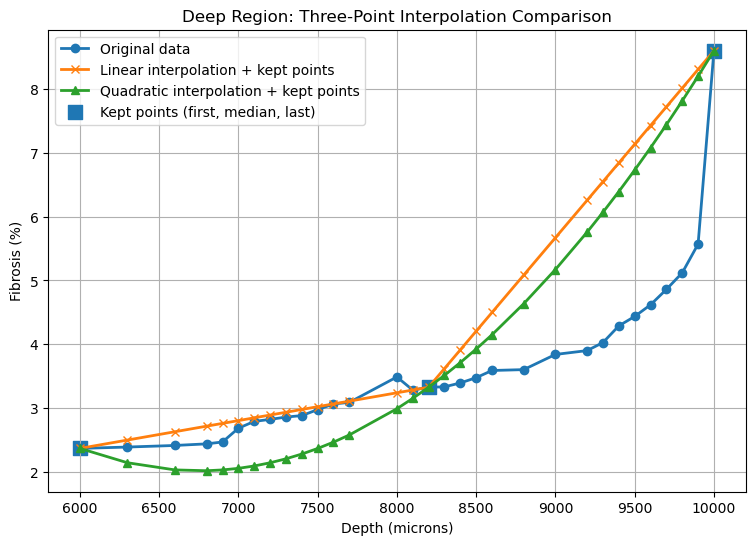

In [13]:
deep_three_compare, deep_three_summary = three_point_interpolation_region(
    results_df, 6000, 10000, "Deep"
)

Three-point interpolation performs poorly in the deep region. The reconstructed curves significantly deviate from the original data, especially where fibrosis increases rapidly. This highlights that sparse data is insufficient for modeling complex, nonlinear trends.

#### **Error**

In [14]:
# ---------------------------
# Summary table
# ---------------------------
three_point_summary_df = pd.DataFrame([
    shallow_three_summary,
    mid_three_summary,
    deep_three_summary
])

print("\nThree-point interpolation error summary:")
print(three_point_summary_df)


Three-point interpolation error summary:
    Region  Linear mean abs error  Quadratic mean abs error  \
0  Shallow               0.121692                  0.083225   
1      Mid               0.033109                  0.058709   
2     Deep               1.029052                  1.058373   

   Linear mean percent error  Quadratic mean percent error  
0                  11.878741                      8.823684  
1                   1.807070                      3.076063  
2                  24.591316                     27.290016  


The error summary shows a substantial increase in error when only three points are used, especially in the deep region. This reinforces that interpolation accuracy depends heavily on data density, and sparse datasets lead to unreliable predictions.

## **Verify and validate your analysis:** 

To verify the accuracy of our analysis, we performed several internal consistency checks throughout the data processing and modeling steps. First, we confirmed that pixel counts were computed correctly by ensuring that the sum of white and black pixels matched the total number of pixels in each image. This verification step ensured that no data was lost or miscounted during image processing. Additionally, we visually inspected several sample images and their corresponding binary masks to confirm that white pixels accurately represented fibrotic tissue and that thresholding was applied consistently across all images. We also verified that depth values were correctly paired with each image by cross-referencing filenames with the provided dataset.

To further verify our computational results, we examined the generated plots to ensure that trends were reasonable and consistent with expectations. The observed increase in fibrosis with depth aligned with the raw data points, and the moving average trend line behaved as expected, smoothing noise without distorting the overall pattern. Interpolation results were also verified by comparing predicted values to actual data points that were intentionally removed. The relatively low error in shallow and mid-depth regions confirmed that the interpolation functions were implemented correctly.

To validate our findings, we compared our results to established biological understanding of fibrosis progression. In diseases such as idiopathic pulmonary fibrosis, fibrotic tissue is known to accumulate unevenly and can become more severe in certain regions of the lung. Our finding that fibrosis increases with depth and exhibits non-uniform distribution is consistent with this understanding. Additionally, the reduced accuracy of interpolation in deeper regions aligns with the expectation that more complex and nonlinear biological processes are harder to model with simple mathematical approximations.

Together, these verification and validation steps support the reliability of our analysis and increase confidence that our results accurately reflect both the dataset and the underlying biological phenomena.

## **Conclusions and Ethical Implications:** 

This analysis demonstrates that fibrotic tissue is not uniformly distributed throughout lung tissue and instead increases with depth. The results show a gradual rise in fibrosis at shallow and mid-depth regions, followed by a more rapid and pronounced increase in deeper regions. This suggests that fibrosis progression is both depth-dependent and nonlinear, with more severe tissue remodeling occurring deeper within the lung. Additionally, our interpolation analysis revealed that predictions based on dense datasets are generally reliable in regions with smooth trends, but become less accurate in areas where fibrosis changes rapidly. When data is limited, prediction accuracy decreases significantly, especially in complex regions.

These findings highlight the importance of sufficient data sampling when modeling biological systems. Relying on sparse data can lead to misleading conclusions, particularly in regions where disease progression is highly variable. From a biomedical perspective, this suggests that clinical imaging and sampling strategies should aim to capture deeper and more variable regions of tissue to better understand disease severity.

From an ethical standpoint, this work raises important considerations regarding the use of computational models in healthcare and research. If interpolation or predictive modeling is used to estimate disease severity in patients, inaccurate predictions—especially those based on limited data—could lead to misdiagnosis or inappropriate treatment decisions. Therefore, it is essential that models are used cautiously and that their limitations are clearly communicated. Additionally, because this dataset is derived from unpublished biomedical research, ethical responsibility includes ensuring proper data handling, respecting data ownership, and accurately representing results without overstating conclusions.

Overall, this project emphasizes both the power and limitations of computational analysis in understanding disease, and underscores the need for careful interpretation, sufficient data collection, and ethical responsibility when applying these methods in real-world biomedical contexts.

## **Limitations and Future Work:**

This project has several limitations related to both the dataset and the analytical methods used. First, the dataset is relatively small and lacks clinical metadata, such as patient information or disease stage, which limits the ability to generalize findings to broader populations. Additionally, the analysis assumes that the segmentation masks perfectly represent fibrotic tissue; however, any inaccuracies in image segmentation could introduce error into the calculated fibrosis percentages. Variability in imaging conditions, such as differences in resolution or lighting, may also affect pixel-based measurements and contribute to noise in the data.

Another limitation is the assumption that depth is the primary factor influencing fibrosis distribution. While depth provides useful spatial context, fibrosis progression is likely influenced by many other biological and environmental factors that are not captured in this dataset. Furthermore, the interpolation methods used in this study (linear and quadratic) are relatively simple and may not fully capture complex, nonlinear patterns observed in deeper tissue regions. This is especially evident in the decreased accuracy of predictions in the deep region and when using limited data points.

For future work, several improvements could enhance the robustness and impact of this analysis. Increasing the dataset size and incorporating additional samples would improve statistical reliability and allow for more detailed analysis. Including clinical or biological metadata could also provide deeper insight into the factors driving fibrosis progression. More advanced modeling techniques, such as spline interpolation, machine learning models, or nonlinear regression, could be explored to better capture complex trends in the data. Additionally, improving segmentation accuracy through automated or AI-based image processing methods could reduce error in fibrosis quantification.

Finally, future studies could expand beyond depth-based analysis to investigate spatial patterns in multiple dimensions or across different regions of the lung. This would provide a more comprehensive understanding of fibrosis distribution and progression, ultimately contributing to more accurate modeling and potential clinical applications.

## **References:**

Centers for Disease Control and Prevention. (2023). Chronic respiratory diseases. https://www.cdc.gov

National Heart, Lung, and Blood Institute. (2022). Idiopathic pulmonary fibrosis. https://www.nhlbi.nih.gov

University of Virginia School of Medicine, Peirce-Cottler Lab & Kim Lab. (Unpublished). Lung tissue imaging dataset with segmentation masks.